<a href="https://colab.research.google.com/github/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/blob/main/Notebooks/1_Data_analitics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p align="center">
  <img src="https://github.com/paulmunozpauta/Curso_Introduccion_Ciencia_Datos/raw/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>

<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Introducción a la Ciencia de Datos</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Introducción a la Ciencia de Datos
## Módulo 2: Preparación de datos para análisis


En este notebook trabajaremos con una serie diaria de precipitación de la estación **Bernardo O'Higgins, Chillán**, obtenida desde el Explorador Climático CR2.

El objetivo es aprender a:

- cargar un archivo de datos en Google Colab;
- importar datos con Python;
- trabajar con un `DataFrame`;
- explorar la estructura de una base de datos;
- preparar una variable de fecha;
- identificar datos faltantes;
- realizar una primera visualización;
- exportar los datos procesados.

## 1. Importar las librerías

En Python, muchas funcionalidades se encuentran organizadas en **librerías**.

En este notebook utilizaremos:

- `pandas` para leer, organizar y procesar datos.
- `matplotlib` para realizar gráficos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Cargar el archivo de datos

Google Colab funciona en la nube. Por esta razón, podemos cargar archivos desde nuestro computador al entorno de trabajo de Colab.

Ejecuta la siguiente celda y selecciona el archivo:

`BernardoOHigginsChillan.xlsx`

In [2]:
from google.colab import files

uploaded = files.upload()

Saving BernardoOHigginsChillan.xlsx to BernardoOHigginsChillan.xlsx


## 3. Leer el archivo con Pandas

El archivo contiene una hoja llamada `Serie`.

Utilizaremos la función `read_excel()` de Pandas para importar los datos.

In [20]:
datos = pd.read_excel("BernardoOHigginsChillan.xlsx", sheet_name="Serie")

## 4. ¿Qué es un DataFrame?

Un **DataFrame** es una estructura de datos organizada en filas y columnas.

Es similar a una hoja de cálculo de Excel, pero permite procesar y analizar los datos mediante código.

In [21]:
datos.head()

,agno,mes,dia,valor
0,1950,1,1,0.0
1,1950,1,2,0.0
2,1950,1,3,0.0
3,1950,1,4,0.0
4,1950,1,5,0.0


### Primeras y últimas observaciones

La función `head()` muestra las primeras filas del DataFrame, mientras que `tail()` permite visualizar las últimas.

In [6]:
datos.head()

,agno,mes,dia,valor
0,1950,1,1,0.0
1,1950,1,2,0.0
2,1950,1,3,0.0
3,1950,1,4,0.0
4,1950,1,5,0.0


In [22]:
datos.tail()

,agno,mes,dia,valor
25532,2026,8,15,4.2
25533,2026,8,16,0.0
25534,2026,8,17,0.0
25535,2026,8,18,0.0
25536,2026,8,19,0.0


## 5. Explorar la estructura de los datos

Antes de realizar cualquier análisis es importante conocer cómo está organizada nuestra base de datos.

Revisaremos:

- número de filas y columnas;
- nombres de las variables;
- tipos de datos;
- información general del DataFrame.

In [8]:
datos.shape

(25537, 4)

In [9]:
datos.columns

Index(['agno', 'mes', 'dia', 'valor'], dtype='object')

In [10]:
datos.dtypes

,0
agno,int64
mes,int64
dia,int64
valor,float64


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25537 entries, 0 to 25536
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   agno    25537 non-null  int64  
 1   mes     25537 non-null  int64  
 2   dia     25537 non-null  int64  
 3   valor   25537 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 798.2 KB


## 6. Seleccionar una columna

Podemos acceder a una variable del DataFrame utilizando el nombre de su columna.

En este caso, `valor` corresponde a la precipitación diaria expresada en milímetros.

In [23]:
datos["valor"]

,valor
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
25532,4.2
25533,0.0
25534,0.0
25535,0.0


In [24]:
datos["valor"].head(10)

,valor
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


## 7. Crear una variable de fecha

Actualmente el año, mes y día se encuentran almacenados en columnas independientes.

Para analizar una serie de tiempo es más conveniente disponer de una única variable de tipo fecha.

In [25]:
datos["fecha"] = pd.to_datetime(
    dict(
        year=datos["agno"],
        month=datos["mes"],
        day=datos["dia"]
    )
)

In [26]:
datos.head()

,agno,mes,dia,valor,fecha
0,1950,1,1,0.0,1950-01-01
1,1950,1,2,0.0,1950-01-02
2,1950,1,3,0.0,1950-01-03
3,1950,1,4,0.0,1950-01-04
4,1950,1,5,0.0,1950-01-05


In [27]:
datos.dtypes

,0
agno,int64
mes,int64
dia,int64
valor,float64
fecha,datetime64[ns]


Para facilitar el trabajo, podemos colocar la fecha al inicio del DataFrame.

In [28]:
datos = datos[["fecha", "agno", "mes", "dia", "valor"]]

datos.head()

,fecha,agno,mes,dia,valor
0,1950-01-01,1950,1,1,0.0
1,1950-01-02,1950,1,2,0.0
2,1950-01-03,1950,1,3,0.0
3,1950-01-04,1950,1,4,0.0
4,1950-01-05,1950,1,5,0.0


## 8. Renombrar variables

Los datos reales no siempre utilizan nombres de variables fáciles de interpretar.

Podemos cambiar los nombres sin modificar los datos originales.

In [29]:
datos = datos.rename(columns={
    "agno": "año",
    "valor": "precipitacion_mm"
})

datos.head()

,fecha,año,mes,dia,precipitacion_mm
0,1950-01-01,1950,1,1,0.0
1,1950-01-02,1950,1,2,0.0
2,1950-01-03,1950,1,3,0.0
3,1950-01-04,1950,1,4,0.0
4,1950-01-05,1950,1,5,0.0


## 9. Identificar datos faltantes

Los datos observados pueden contener registros sin información.

Antes de realizar cualquier análisis es importante identificar estos valores.

In [30]:
datos.isna().sum()

,0
fecha,0
año,0
mes,0
dia,0
precipitacion_mm,0


## 10. Una primera descripción de los datos

Pandas permite obtener rápidamente algunas características generales de las variables numéricas.

In [31]:
datos["precipitacion_mm"].describe()

,precipitacion_mm
count,25537.000000
mean,2.712742
std,8.705772
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,153.700000


In [32]:
datos["precipitacion_mm"].max()

153.7

In [33]:
datos.loc[datos["precipitacion_mm"].idxmax()]

,16614
fecha,2002-02-26 00:00:00
año,2002
mes,2
dia,26
precipitacion_mm,153.7


## 11. Primera visualización de la serie

Una serie temporal permite observar cómo cambia una variable a través del tiempo.

Por ahora realizaremos una visualización simple. En el siguiente módulo aprenderemos a construir e interpretar gráficos con mayor detalle.

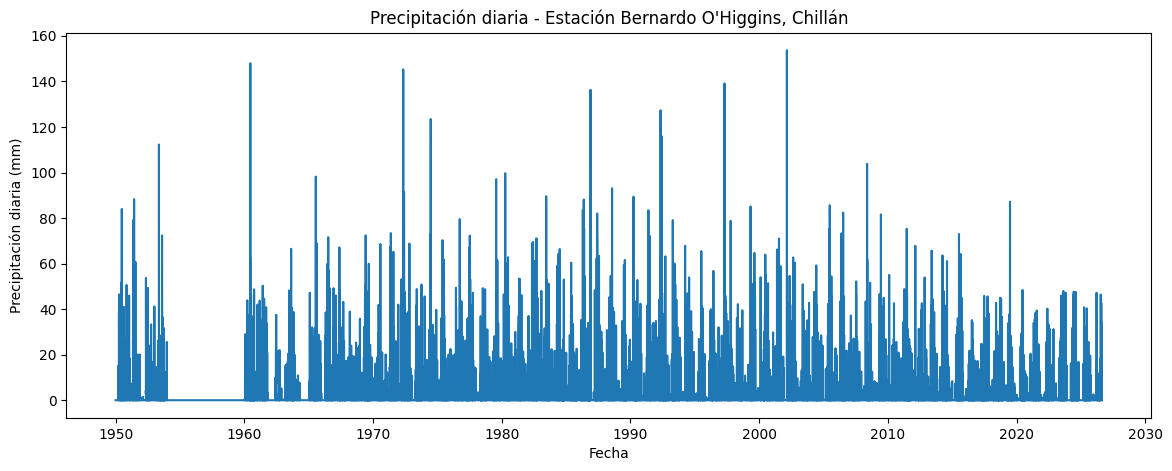

In [34]:
plt.figure(figsize=(14, 5))

plt.plot(
    datos["fecha"],
    datos["precipitacion_mm"]
)

plt.xlabel("Fecha")
plt.ylabel("Precipitación diaria (mm)")
plt.title("Precipitación diaria - Estación Bernardo O'Higgins, Chillán")

plt.show()

### Visualizar un periodo específico

También podemos seleccionar solamente una parte de la serie.

A continuación observaremos la precipitación durante el año 2025.

In [36]:
datos_2025 = datos[datos["año"] == 2025]

datos_2025

,fecha,año,mes,dia,precipitacion_mm
24959,2025-01-01,2025,1,1,0.0
24960,2025-01-02,2025,1,2,0.0
24961,2025-01-03,2025,1,3,0.0
24962,2025-01-04,2025,1,4,0.0
24963,2025-01-05,2025,1,5,0.0
...,...,...,...,...,...
25317,2025-12-26,2025,12,26,0.0
25318,2025-12-27,2025,12,27,0.0
25319,2025-12-28,2025,12,28,0.0
25320,2025-12-29,2025,12,29,0.0


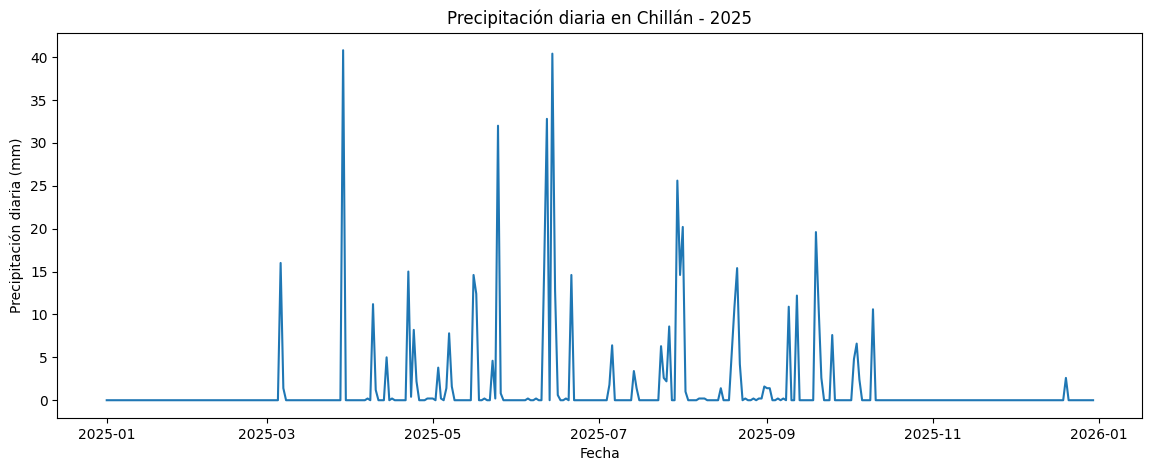

In [37]:
plt.figure(figsize=(14, 5))

plt.plot(
    datos_2025["fecha"],
    datos_2025["precipitacion_mm"]
)

plt.xlabel("Fecha")
plt.ylabel("Precipitación diaria (mm)")
plt.title("Precipitación diaria en Chillán - 2025")

plt.show()

## 12. Exportar los datos procesados

Después de modificar o procesar una base de datos podemos guardar el resultado en un nuevo archivo.

Utilizaremos el formato CSV (`Comma-Separated Values`), ampliamente utilizado para almacenar datos tabulares.

In [38]:
datos.to_csv(
    "precipitacion_chillan_procesada.csv",
    index=False
)

In [39]:
files.download("precipitacion_chillan_procesada.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Actividad práctica

Ahora debes reproducir el procedimiento utilizando la serie de precipitación de **otra estación** obtenida desde el Explorador Climático CR2.

## Actividades

1. Carga el archivo en Google Colab.
2. Importa la hoja que contiene la serie de datos.
3. Guarda los datos en un DataFrame.
4. Muestra las primeras y últimas filas.
5. Determina el número de filas y columnas.
6. Identifica los nombres y tipos de las variables.
7. Construye una columna de fecha.
8. Renombra las variables para que sean fáciles de interpretar.
9. Determina si existen datos faltantes.
10. Obtén el valor máximo de precipitación.
11. Identifica la fecha en que ocurrió.
12. Realiza un gráfico de la serie completa.
13. Selecciona un año y realiza un segundo gráfico.
14. Exporta el DataFrame procesado como archivo CSV.